In [2]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import preliz as pz

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='pytensor')

SEED = 12

## Parte 1: Modelos Lineales Generalizados (GLMs)


### 1.
Para el Dataset elegido, elegir variables para aplicar un modelo GLM Bayesiano
(pueden considerar una variable independiente y una variable respuesta, o trabajar
con mas de una para cada categorıa) y presentar un brvee resumen de cada una y
la relaci ́on entre variables (si ya lo hicieron en la Parte 0, no es necesario repetirlo).

In [3]:
pizza = pd.read_csv('../data/pizza_sales.csv')

In [4]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [23]:
pizza.query('order_date >= "2015-06-01" & order_date < "2015-07-01"', inplace=True)

In [24]:
conteo = pizza.groupby(['order_date', 'order_hour']).size().reset_index(name='sales')

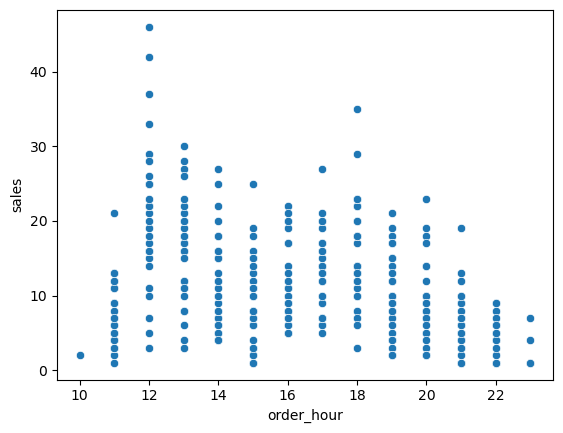

In [26]:
sns.scatterplot(data=conteo, x='order_hour', y='sales');

### 2.
Seleccionar un modelo GLM adecuado al tipo de variable respuesta:  
• Continua: regresion lineal o con varianza variable.   
• Binaria: regresion logıstica.  
• Modelo con estructura jerarquica  
• (Opcional) De conteo: regresion Poisson o negativa binomial.  

In [80]:
conteo.sales.mean(), conteo.sales.var()

(np.float64(11.402266288951841), np.float64(54.2581766675251))

Como nuestros datos son de conteo, usamos una regresión con familia Negativa Binomial porque encontramos sobre-dispersión (varianza >>> media).

In [51]:
modelo = bmb.Model('sales ~ poly(order_hour, 2)', conteo, family='negativebinomial')

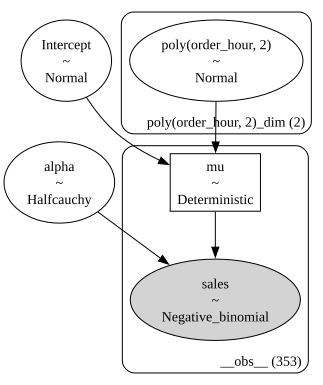

In [52]:
modelo.build()
modelo.graph()

In [53]:
idata = modelo.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 2)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 56 seconds.



### 3.
Formular las ecuaciones del modelo y justificar las distribuciones elegidas.


### 4.
Interpretar los parametros de la distribucion posterior: medias, intervalos de credibilidad, relacion con los predictores.


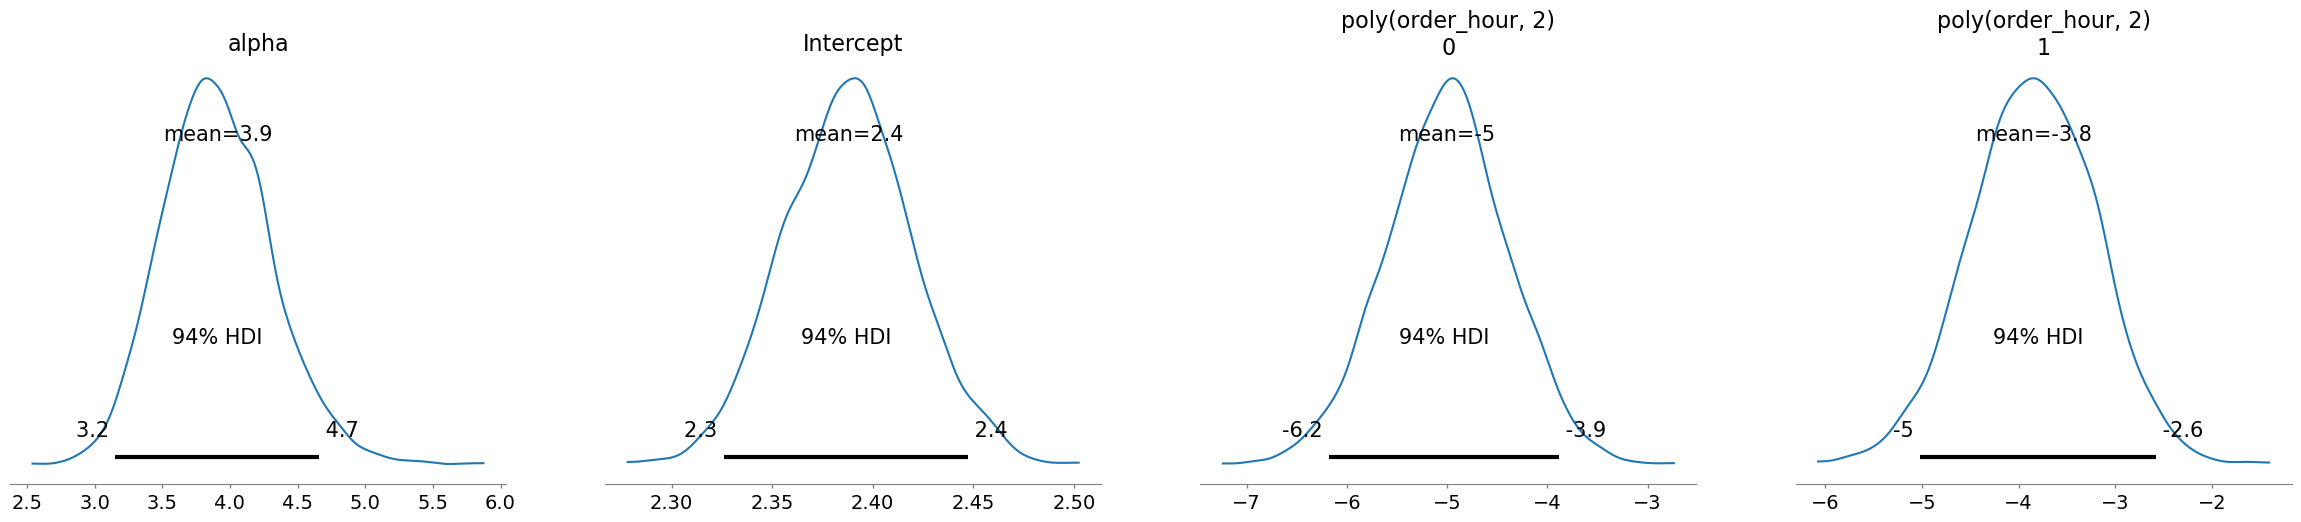

In [54]:
az.plot_posterior(idata);

AGREGAR INTERPRETACION

Default computed for conditional variable: order_hour


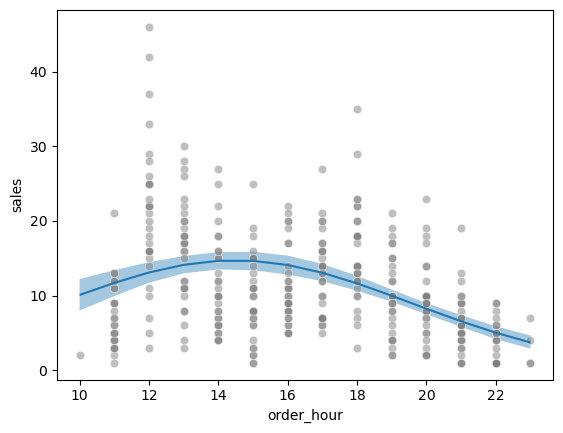

In [55]:
bmb.interpret.plot_predictions(modelo, idata, conditional=['order_hour'])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey');

TAMBIEN


### 5.
Realizar predicciones a posteriori e interpretarlas en el contexto del problema.


In [56]:
modelo.predict(idata, kind='response', data=conteo)

Default computed for conditional variable: order_hour


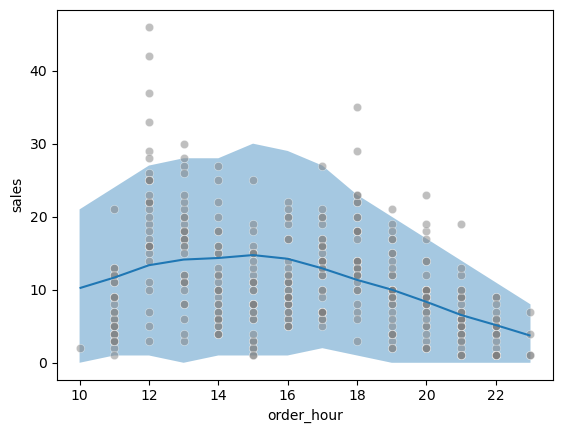

In [57]:
bmb.interpret.plot_predictions(modelo, idata, conditional=['order_hour'], pps=True)
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey');

INTERPRETAR

### 6.
Si el modelo lo permite, incluir predictores categoricos, interacciones o estructura jerarquica.

Suponemos que los días viernes y sábados se venden más pizzas y lo consideramos un grupo aparte.

In [63]:
conteo['day_of_week'] = conteo['order_date'].dt.day_name()
conteo['saturday_friday'] = conteo['day_of_week'].isin(['Saturday', 'Friday']).astype(int)

In [64]:
modelo_cat = bmb.Model('sales ~ poly(order_hour, 2) + saturday_friday', conteo, family='negativebinomial')

In [65]:
idata_cat = modelo_cat.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 2), saturday_friday]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


In [71]:
modelo_cat.predict(idata_cat, kind='response', data=conteo)

Default computed for conditional variable: order_hour, saturday_friday
Default computed for conditional variable: order_hour, saturday_friday


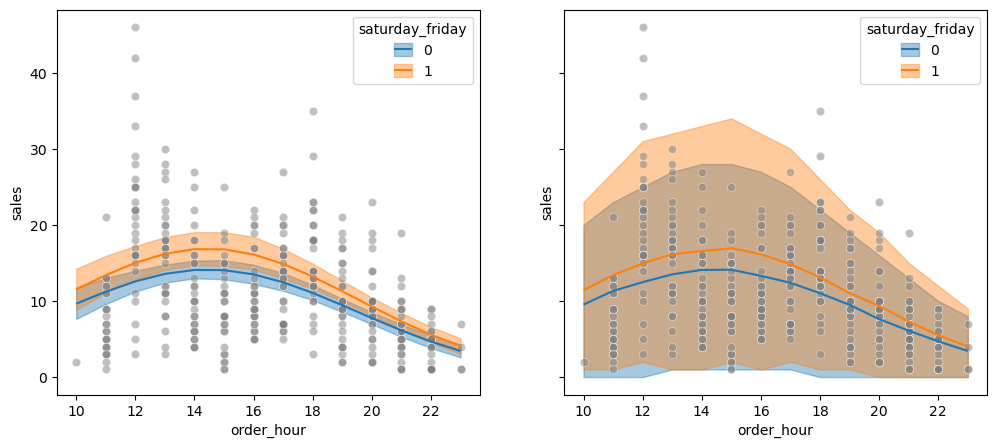

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_cat, idata_cat, conditional=['order_hour', 'saturday_friday'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_cat, idata_cat, conditional=['order_hour', 'saturday_friday'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);

Efectivamente, para esos días hay mayor cantidad de ventas

### Extra: Splines

In [69]:
num_knots = 6
knots = np.linspace(10, 23, num_knots+2)[1:-1]

In [70]:
modelo_spline = bmb.Model('sales ~ bs(order_hour, knots=knots, degree=3)', conteo, family='negativebinomial')
idata_spline = modelo_spline.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, bs(order_hour, knots=knots, degree=3)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 85 seconds.


In [73]:
modelo_spline.predict(idata_spline, kind='response', data=conteo)

Default computed for conditional variable: order_hour
Default computed for conditional variable: order_hour


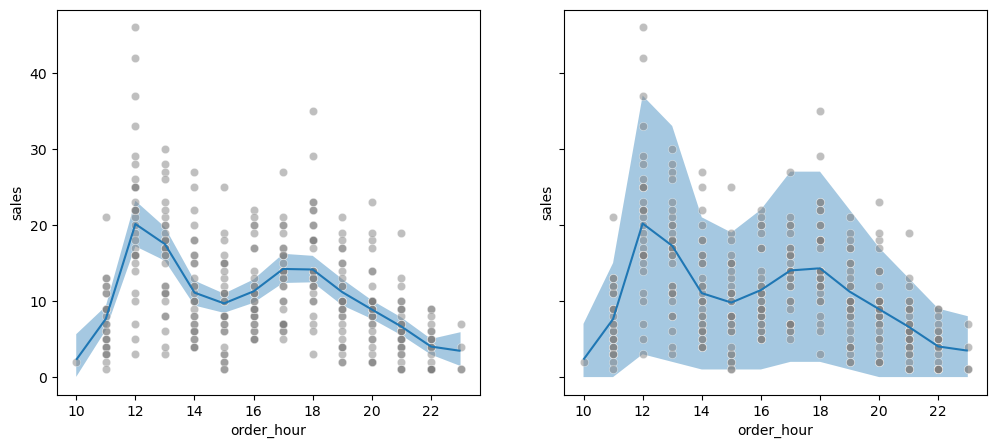

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_spline, idata_spline, conditional=['order_hour'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_spline, idata_spline, conditional=['order_hour'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);

In [76]:
modelo_spline_cat = bmb.Model('sales ~ bs(order_hour, knots=knots, degree=3) + saturday_friday', conteo, family='negativebinomial')
idata_spline_cat = modelo_spline_cat.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, bs(order_hour, knots=knots, degree=3), saturday_friday]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.


In [77]:
modelo_spline_cat.predict(idata_spline_cat, kind='response', data=conteo)

Default computed for conditional variable: order_hour, saturday_friday
Default computed for conditional variable: order_hour, saturday_friday


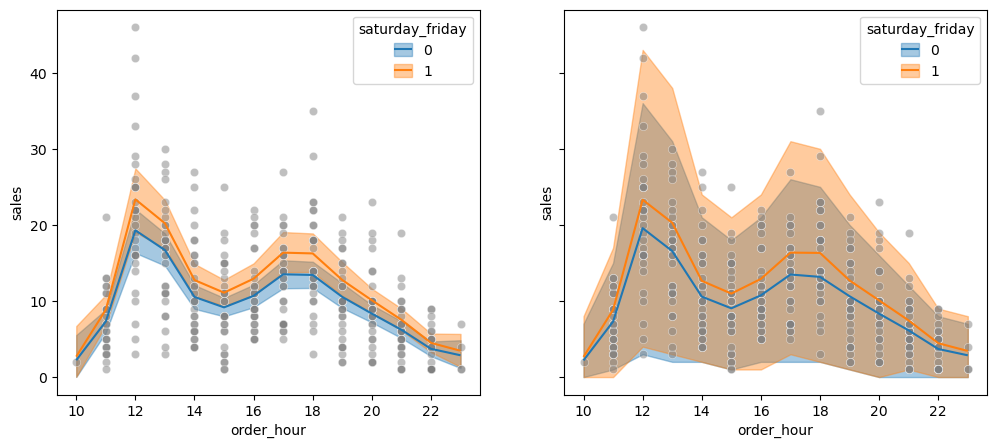

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_spline_cat, idata_spline_cat, conditional=['order_hour', 'saturday_friday'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_spline_cat, idata_spline_cat, conditional=['order_hour', 'saturday_friday'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);